<a href="https://colab.research.google.com/github/simpli-cheekah/Ecom_Netflix_Analysis/blob/main/AnalystLab_Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AnalystLab Africa Data Analytics Internship: Batch B
## Project 1: E-commerce Transactions Data Cleaning & Exploratory Data Analysis (EDA)
Author: Chika Nkemjika

Date: June 2026  

---
### Project Objective
The goal of this project is to transform a messy, raw e-commerce dataset into a structured, analysis-ready format. The primary focus is on rigorous data cleaning methodology, validation, and documenting structural changes, followed by exploratory analysis to uncover key purchasing patterns.

In [1]:
# STEP 1: Load the tools we need
import pandas as pd

# STEP 2: Load the dataset into Colab's memory
# We add encoding='ISO-8859-1' because e-commerce data has special characters (like currency symbols)
df_retail = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

# STEP 3: Show the first 5 rows so we can see what the data looks like
df_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Task 1: Dataset Understanding
Before cleaning, I loaded the raw transaction data to analyze its structure, shapes, and structural data types.

In [2]:
# STEP 4: Check the number of rows and columns
print("--- DATASET SIZE ---")
print(f"Rows: {df_retail.shape[0]}")
print(f"Columns: {df_retail.shape[1]}")
print("\n--- DATA TYPES AND SUMMARY ---")

# STEP 5: See column names, data types, and count of actual data
df_retail.info()

--- DATASET SIZE ---
Rows: 474379
Columns: 8

--- DATA TYPES AND SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474379 entries, 0 to 474378
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    474379 non-null  object 
 1   StockCode    474379 non-null  object 
 2   Description  472976 non-null  object 
 3   Quantity     474379 non-null  int64  
 4   InvoiceDate  474379 non-null  object 
 5   UnitPrice    474378 non-null  float64
 6   CustomerID   356968 non-null  float64
 7   Country      474378 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 29.0+ MB


## Task 2: Data Cleaning & Validation

### 1. Handling Missing Values
* Description Column: A small number of descriptions were missing. These were filled with "Unknown" to retain the sales records.
* CustomerID Column: Over 117,000 transactions lacked a Customer ID. Dropping these rows would severely skew revenue metrics. Therefore, missing values were populated with 0 to explicitly represent "Guest Checkouts/Unregistered Users".

In [3]:
# 1. Check exactly how many missing values are in each column before cleaning
print("--- Missing Values Before Cleaning ---")
print(df_retail.isnull().sum())

# 2. Handle missing Descriptions by filling them with 'Unknown'
df_retail['Description'] = df_retail['Description'].fillna('Unknown')

# 3. Handle missing CustomerIDs by filling them with 0 (representing Guest/Unregistered users)
df_retail['CustomerID'] = df_retail['CustomerID'].fillna(0)

print("\n--- Missing Values After Cleaning ---")
print(df_retail.isnull().sum())

--- Missing Values Before Cleaning ---
InvoiceNo           0
StockCode           0
Description      1403
Quantity            0
InvoiceDate         0
UnitPrice           1
CustomerID     117411
Country             1
dtype: int64

--- Missing Values After Cleaning ---
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      1
CustomerID     0
Country        1
dtype: int64


### 2. Removing Duplicate Records
Duplicate entries can falsely inflate sales numbers. I checked for identical rows across all columns and removed the duplicate records to ensure data integrity.

In [4]:
# 1. Count how many duplicate rows exist
duplicate_count = df_retail.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# 2. Remove the duplicates and keep only the first occurrence
df_retail = df_retail.drop_duplicates()

# 3. Verify the new size of the dataset
print(f"New dataset size after removing duplicates: {df_retail.shape[0]} rows")

Number of duplicate rows found: 4249
New dataset size after removing duplicates: 470130 rows


### 3. Data Standardization & Type Casting
* Converted InvoiceDate from a text object to a standard datetime format using errors='coerce' to handle anomalies.
* Stripped trailing and leading whitespaces from Description and Country to prevent duplicate categories.
* Converted CustomerID from a float decimal to a clean integer.

In [6]:
# REVISED STEP 3: Convert InvoiceDate and handle weird formats gracefully
# errors='coerce' tells Python: "If you find a broken date like '11/16', don't crash, just mark it as empty."
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'], errors='coerce')

# Drop any rows where the date was completely broken and couldn't be fixed
df_retail = df_retail.dropna(subset=['InvoiceDate'])

# Clean up text columns (remove accidental spaces)
df_retail['Description'] = df_retail['Description'].astype(str).str.strip()
df_retail['Country'] = df_retail['Country'].astype(str).str.strip()

# Convert CustomerID to a whole number integer
df_retail['CustomerID'] = df_retail['CustomerID'].astype(int)

print("Standardization complete! Let's check the data types now:")
df_retail.info()

/tmp/ipykernel_3794/3645619318.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_retail['Description'] = df_retail['Description'].astype(str).str.strip()
/tmp/ipykernel_3794/3645619318.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_retail['Country'] = df_retail['Country'].astype(str).str.strip()
/tmp/ipykernel_3794/3645619318.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

Standardization complete! Let's check the data types now:
<class 'pandas.core.frame.DataFrame'>
Index: 470129 entries, 0 to 474377
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    470129 non-null  object        
 1   StockCode    470129 non-null  object        
 2   Description  470129 non-null  object        
 3   Quantity     470129 non-null  int64         
 4   InvoiceDate  470129 non-null  datetime64[ns]
 5   UnitPrice    470129 non-null  float64       
 6   CustomerID   470129 non-null  int64         
 7   Country      470129 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 32.3+ MB


### 4. Data Validation (Filtering Anomalies)
The raw dataset contains negative values in the Quantity column, which signify product returns or cancelled orders. For this primary sales and revenue analysis, these rows were filtered out to focus exclusively on completed purchases.

In [7]:
# 1. Check for negative quantities or unit prices
neg_quantity = (df_retail['Quantity'] <= 0).sum()
neg_price = (df_retail['UnitPrice'] < 0).sum()

print(f"Rows with negative or zero quantities: {neg_quantity}")
print(f"Rows with negative prices: {neg_price}")

# 2. Keep ONLY rows where Quantity is greater than 0 and UnitPrice is 0 or greater
df_retail = df_retail[(df_retail['Quantity'] > 0) & (df_retail['UnitPrice'] >= 0)]

print(f"Final clean dataset size: {df_retail.shape[0]} rows")

Rows with negative or zero quantities: 9636
Rows with negative prices: 2
Final clean dataset size: 460491 rows


## Task 3: Exploratory Data Analysis (EDA) - Summary Statistics
In this section, I calculate the summary statistics (Mean, Median, Minimum, Maximum, and Standard Deviation) for the numerical columns in the dataset to understand the spread of our data.

In [8]:
# Tell Python to show the mean, median (50%), min, max, and std deviation
df_retail[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,460491.000000,460491.000000
mean,10.834594,3.921469
std,116.914213,36.920479
min,1.000000,0.000000
25%,1.000000,1.250000
50%,4.000000,2.080000
75%,12.000000,4.130000
max,74215.000000,13541.330000


## Task 3 & 4: Data Patterns and Visualizations
In this section, I explore key data patterns through visualization charts, analyzing revenue by country, top products, monthly sales trends, order sizes, and customer types.

/tmp/ipykernel_3794/1974735334.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


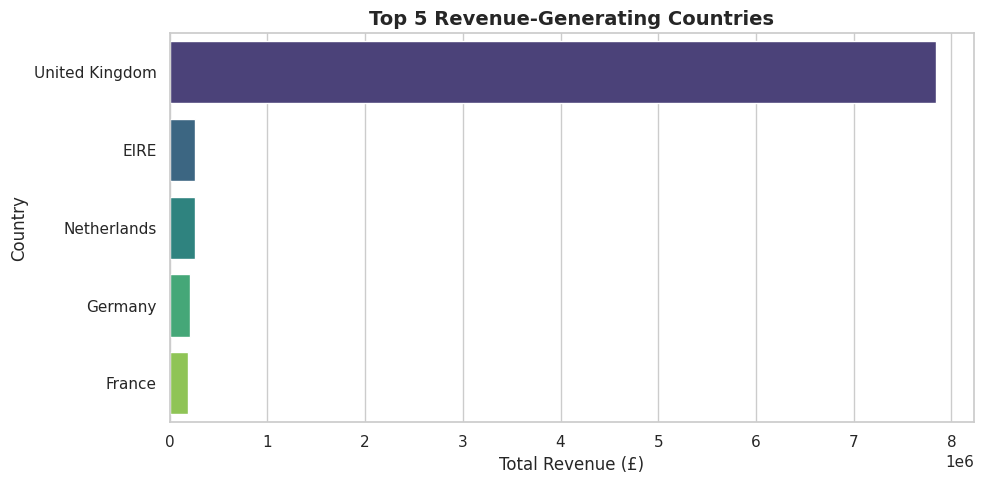

In [9]:
# 1. Create a new column called 'Revenue'
df_retail['Revenue'] = df_retail['Quantity'] * df_retail['UnitPrice']

# 2. Calculate the total revenue per country and select the top 5
top_countries = df_retail.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)

# 3. Load the chart drawing tools
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# 4. Draw the Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 5 Revenue-Generating Countries", fontsize=14, fontweight='bold')
plt.xlabel("Total Revenue (£)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3794/815033134.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="mako")


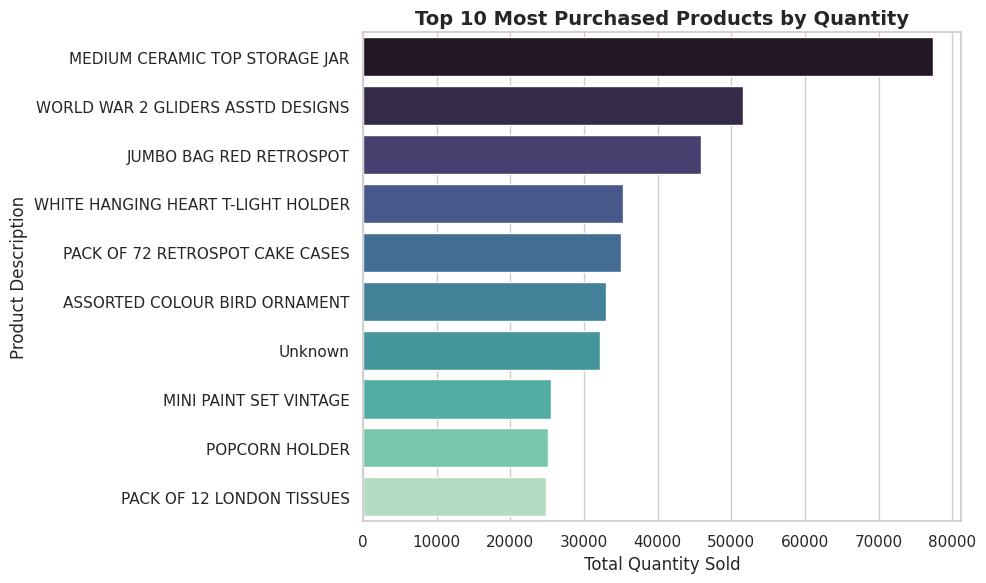

In [10]:
# 1. Calculate top products by summing up the total quantity sold for each item
top_products = df_retail.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# 2. Plot the Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette="mako")
plt.title("Top 10 Most Purchased Products by Quantity", fontsize=14, fontweight='bold')
plt.xlabel("Total Quantity Sold", fontsize=12)
plt.ylabel("Product Description", fontsize=12)
plt.tight_layout()
plt.show()

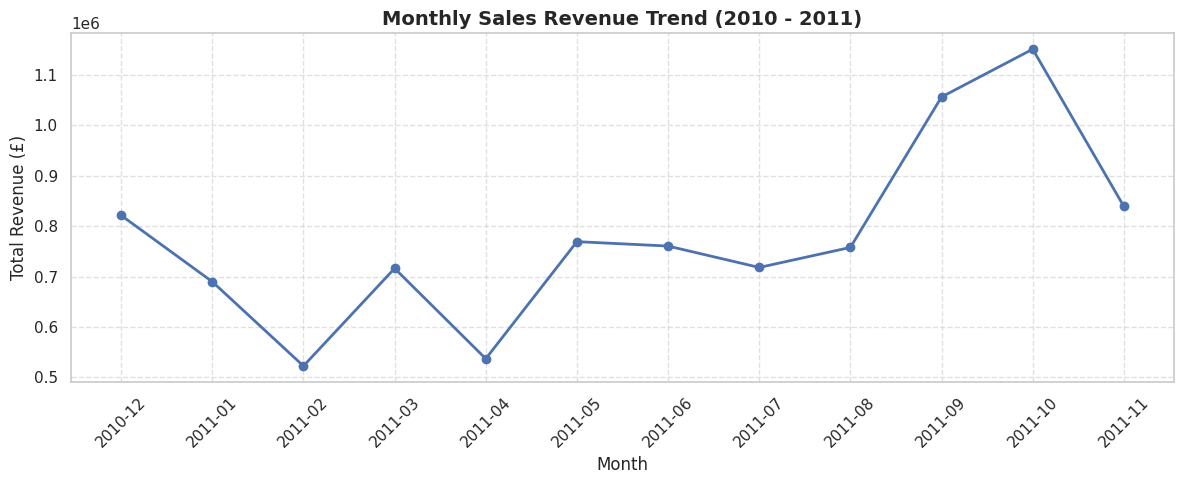

In [11]:
# 1. Create a clean Year-Month column for tracking trends over time
df_retail['YearMonth'] = df_retail['InvoiceDate'].dt.to_period('M').astype(str)
monthly_sales = df_retail.groupby('YearMonth')['Revenue'].sum()

# 2. Plot the Line Chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b', linewidth=2, markersize=6)
plt.title("Monthly Sales Revenue Trend (2010 - 2011)", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue (£)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

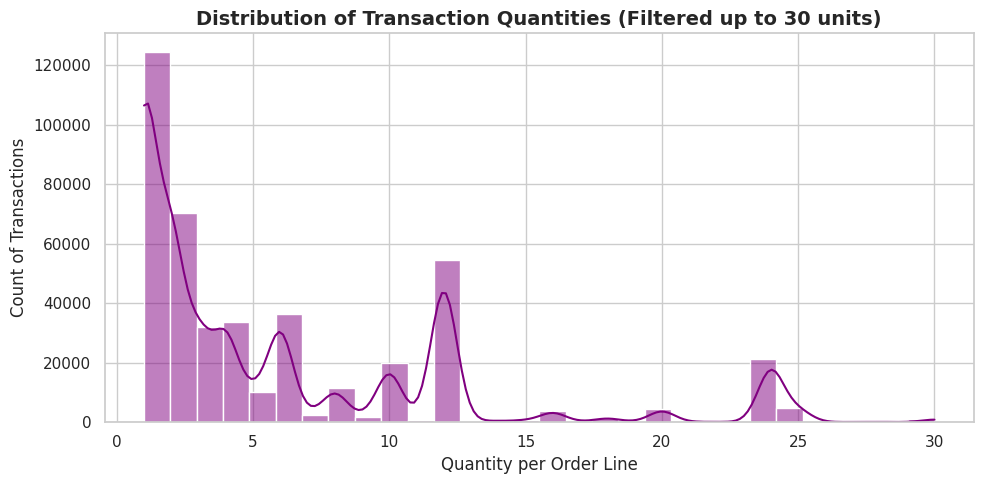

In [12]:
# Plot a Histogram for the distribution of Quantity
# (We filter out extreme wholesale bulk orders above 30 units so we can see normal patterns clearly)
plt.figure(figsize=(10, 5))
sns.histplot(df_retail[df_retail['Quantity'] <= 30]['Quantity'], bins=30, kde=True, color='purple')
plt.title("Distribution of Transaction Quantities (Filtered up to 30 units)", fontsize=14, fontweight='bold')
plt.xlabel("Quantity per Order Line", fontsize=12)
plt.ylabel("Count of Transactions", fontsize=12)
plt.tight_layout()
plt.show()

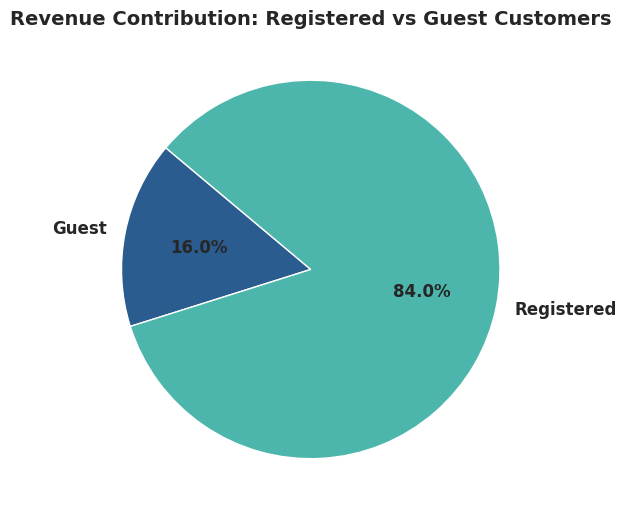

In [14]:
# 1. Group customers into Registered vs Guest based on their ID
df_retail['CustomerType'] = df_retail['CustomerID'].apply(lambda x: 'Registered' if x != 0 else 'Guest')
customer_revenue = df_retail.groupby('CustomerType')['Revenue'].sum()

# 2. Plot using matching Teal and Slate Blue colors to align with your other charts
plt.figure(figsize=(6, 6))
plt.pie(customer_revenue, labels=customer_revenue.index, autopct='%1.1f%%',
        colors=['#2b5c8f', '#4db6ac'], startangle=140,
        textprops={'fontsize': 12, 'weight': 'bold'})
plt.title("Revenue Contribution: Registered vs Guest Customers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 5: Key Insights (E-commerce Analysis)
1. Market Dominance: The United Kingdom is the primary driver of revenue, vastly outperforming international locations like Ireland (EIRE) and the Netherlands.
2. Q4 Sales Spike: Revenue trends show significant monthly stability before experiencing a massive surge from September to November, indicating strong seasonal holiday wholesale purchasing.
3. Transaction Size Patterns: The vast majority of individual transaction lines consist of small batch purchases (1 to 12 items), matching standard retail consumer behavior.
4. Customer Segments: Registered account holders generate 84% of total revenue, proving high brand retention and emphasizing the value of customer loyalty strategies over guest conversions.

# Section 2: Netflix Movies & TV Shows Data Cleaning & EDA
---
## Task 1: Dataset Understanding
Now, I will load the raw Netflix content catalog dataset to analyze its overall size, column data types, unique identifiers, and inspect for missing or inconsistent data patterns.

In [15]:
# Load the Netflix dataset into a brand new variable name: df_netflix
df_netflix = pd.read_csv('netflix_titles.csv')

# Print the size details of the dataset
print("--- NETFLIX DATASET SIZE ---")
print(f"Rows: {df_netflix.shape[0]}")
print(f"Columns: {df_netflix.shape[1]}")
print("\n--- DATA TYPES AND SUMMARY ---")

# Show column names, types, and non-missing counts
df_netflix.info()

--- NETFLIX DATASET SIZE ---
Rows: 8807
Columns: 12

--- DATA TYPES AND SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Task 2: Data Cleaning & Validation (Netflix Dataset)

### 1. Handling Missing Values
* director, cast, country: These columns have significant missing values. Since we cannot guess real directors or cast members, we will fill these missing text spaces with "Unknown".
* date_added, rating, duration: These have only a few missing rows. We will drop the tiny handful of rows where these are missing to keep our analysis accurate.

### 2. Standardization & Type Casting
* Convert date_added to a proper datetime format.
* Clean up text formatting by stripping accidental empty spaces from text columns.

In [16]:
# 1. Fill missing text columns with 'Unknown'
df_netflix['director'] = df_netflix['director'].fillna('Unknown')
df_netflix['cast'] = df_netflix['cast'].fillna('Unknown')
df_netflix['country'] = df_netflix['country'].fillna('Unknown')

# 2. Drop rows with missing crucial information (date_added, rating, duration)
df_netflix = df_netflix.dropna(subset=['date_added', 'rating', 'duration'])

# 3. Standardize Date format (strip spaces first, then convert)
df_netflix['date_added'] = df_netflix['date_added'].str.strip()
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'], errors='coerce')

# 4. Remove any duplicate records across the dataset
netflix_dupes = df_netflix.duplicated().sum()
print(f"Number of duplicate rows removed: {netflix_dupes}")
df_netflix = df_netflix.drop_duplicates()

# 5. Verify the clean size
print(f"Final clean Netflix dataset size: {df_netflix.shape[0]} rows")

Number of duplicate rows removed: 0
Final clean Netflix dataset size: 8790 rows


## Task 3 & 4: Netflix Data Patterns and Visualizations
In this section, I analyze the Netflix catalog distribution, tracking Content Type splits, top production countries, content growth over time, common maturity ratings, and dominant genres.

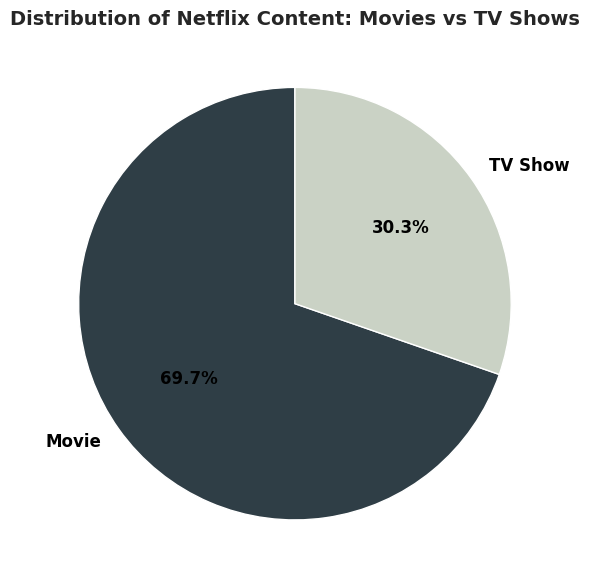

In [28]:
# 1. Count the types of content
type_counts = df_netflix['type'].value_counts()

# 2. Plot Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#2F3E46', '#CAD2C5'], startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'})
plt.title("Distribution of Netflix Content: Movies vs TV Shows", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3794/1081355193.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries_netflix.values, y=top_countries_netflix.index, palette="Greys_r")


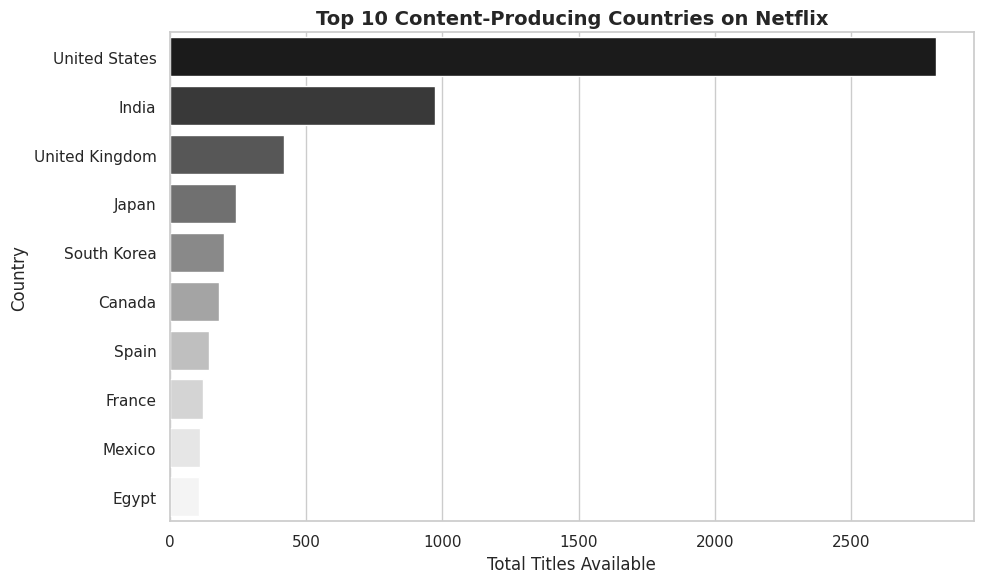

In [31]:
# 1. Get top 10 countries (excluding 'Unknown')
top_countries_netflix = df_netflix[df_netflix['country'] != 'Unknown']['country'].value_counts().head(10)

# 2. Plot Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries_netflix.values, y=top_countries_netflix.index, palette="Greys_r")
plt.title("Top 10 Content-Producing Countries on Netflix", fontsize=14, fontweight='bold')
plt.xlabel("Total Titles Available", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

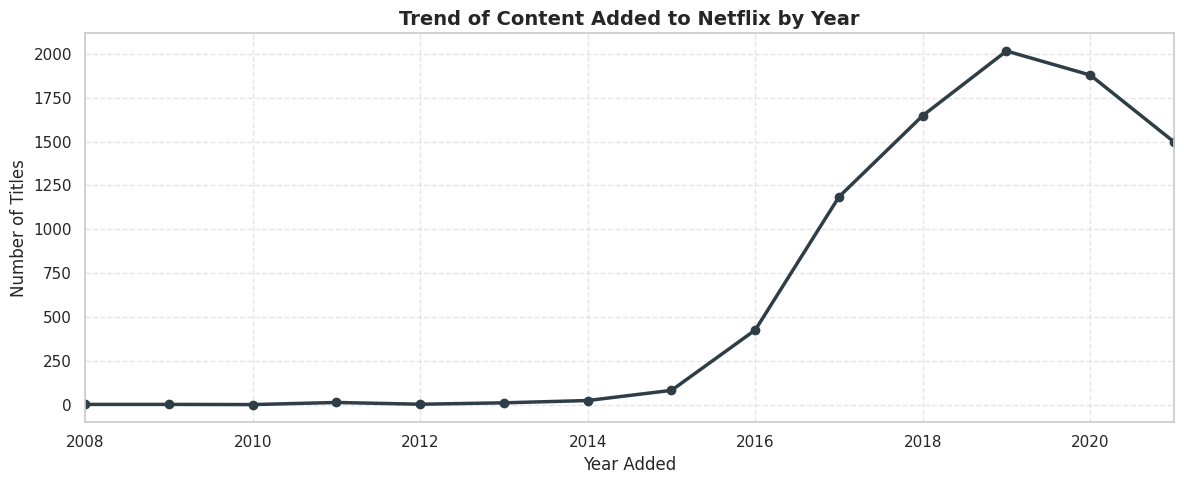

In [29]:
# 1. Extract the year content was added
df_netflix['year_added'] = df_netflix['date_added'].dt.year
content_by_year = df_netflix['year_added'].value_counts().sort_index()

# 2. Plot Line Chart (Filtering out years before 2008 to focus on growth)
plt.figure(figsize=(12, 5))
plt.plot(content_by_year.index, content_by_year.values, marker='o', color='#2F3E46', linewidth=2.5)
plt.title("Trend of Content Added to Netflix by Year", fontsize=14, fontweight='bold')
plt.xlabel("Year Added", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)
plt.xlim(2008, 2021) # Focusing on the core historical growth window of the dataset
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3794/211462868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ratings.index, y=top_ratings.values, palette="bone")


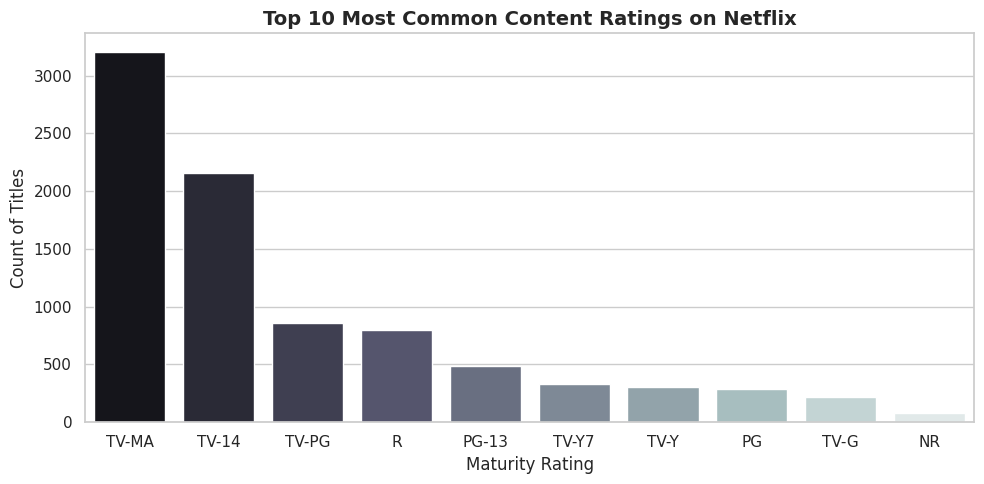

In [32]:
# 1. Get top 10 ratings
top_ratings = df_netflix['rating'].value_counts().head(10)

# 2. Plot Vertical Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=top_ratings.index, y=top_ratings.values, palette="bone")
plt.title("Top 10 Most Common Content Ratings on Netflix", fontsize=14, fontweight='bold')
plt.xlabel("Maturity Rating", fontsize=12)
plt.ylabel("Count of Titles", fontsize=12)
plt.tight_layout()
plt.show()

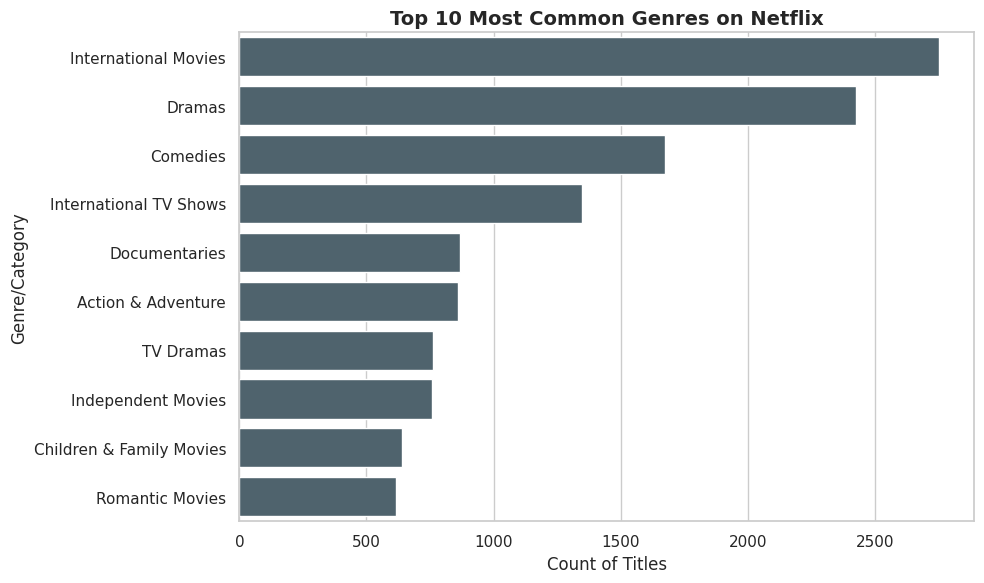

In [39]:
# 1. Split genres (since some rows list multiple genres like 'Comedies, Dramas')
genres = df_netflix['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

# 2. Plot Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, color="#4A6572")
plt.title("Top 10 Most Common Genres on Netflix", fontsize=14, fontweight='bold')
plt.xlabel("Count of Titles", fontsize=12)
plt.ylabel("Genre/Category", fontsize=12)
plt.tight_layout()
plt.show()

## Task 5: Key Insights (Netflix Analysis)

1. Movie-Centric Catalog: Movies make up nearly 70% of the entire Netflix library, showing that Netflix remains a platform focused heavily on films rather than multi-season TV shows.
2. US Market Leadership: The United States is by far the leading producer of content on Netflix, with India coming in as a clear second place due to its massive Bollywood catalog.
3. Exponential Historic Growth: The trend chart highlights a rapid surge in content library growth starting around 2015, peaking around 2019, which matches Netflix's aggressive historic global expansion strategy.
4. Adult and Mature Audiences Target: The dominant content ratings are TV-MA (Mature Audiences) and TV-14 (Parents Strongly Cautioned), proving that Netflix builds its core library primarily for adult and teen demographic groups rather than young children.
5. Dramas and Comedies Rule: International Movies, Dramas, and Comedies are the most highly populated categories on the platform, making up the strategic foundation of Netflix's globally appealing content library.

/tmp/ipykernel_3794/4156377237.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="Blues_r", ax=axes[0, 0])
/tmp/ipykernel_3794/4156377237.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(monthly_sales.index.astype(str), rotation=45)
/tmp/ipykernel_3794/4156377237.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries_retail.values, y=top_countries_retail.index, palette="Purples_r", ax=axes[1, 0])


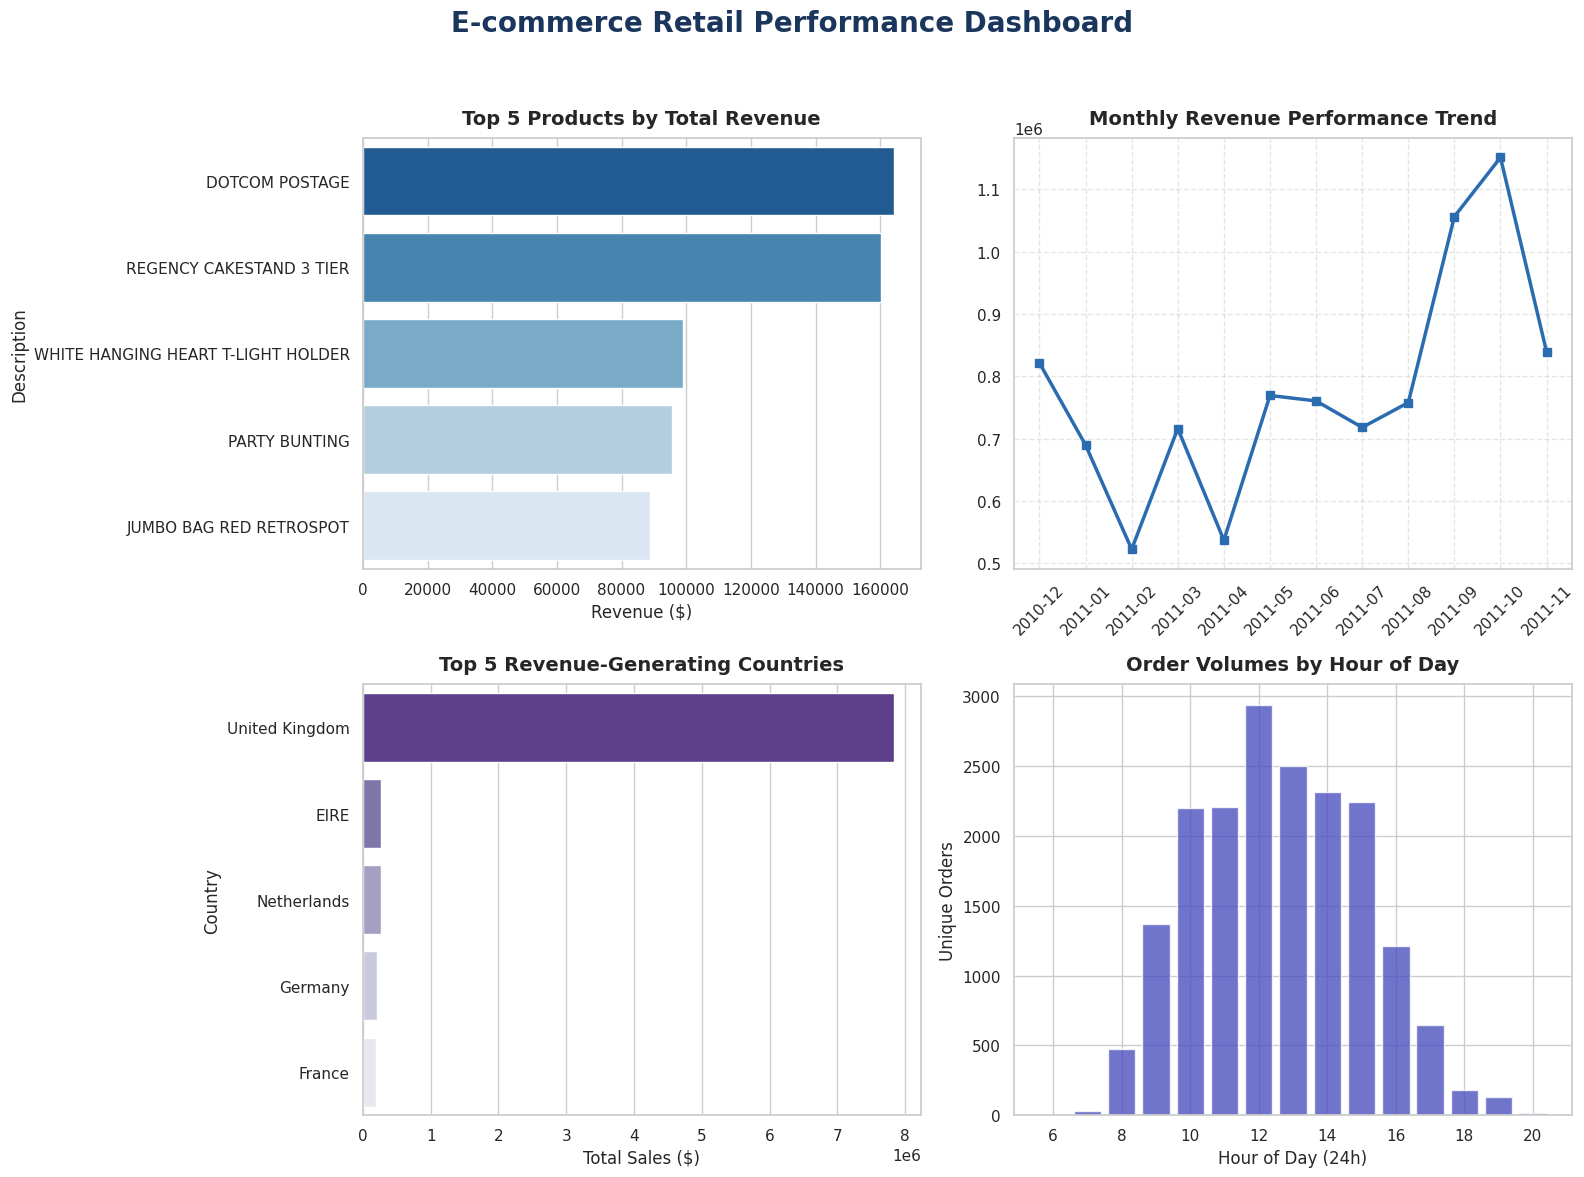

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid for Retail Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("E-commerce Retail Performance Dashboard", fontsize=20, fontweight='bold', color='#1A365D', y=0.98)

# 1. Top Left: Top Products by Revenue (Using 'Revenue')
top_products = df_retail.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_products.values, y=top_products.index, palette="Blues_r", ax=axes[0, 0])
axes[0, 0].set_title("Top 5 Products by Total Revenue", fontsize=14, fontweight='bold', pad=10)
axes[0, 0].set_xlabel("Revenue ($)")

# 2. Top Right: Sales Trend Over Time (Using 'YearMonth' and 'Revenue')
monthly_sales = df_retail.groupby('YearMonth')['Revenue'].sum()
axes[0, 1].plot(monthly_sales.index.astype(str), monthly_sales.values, color='#2B6CB0', marker='s', linewidth=2.5)
axes[0, 1].set_title("Monthly Revenue Performance Trend", fontsize=14, fontweight='bold', pad=10)
axes[0, 1].set_xticklabels(monthly_sales.index.astype(str), rotation=45)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 3. Bottom Left: Top Countries contributing to Sales (Using 'Revenue')
top_countries_retail = df_retail.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_countries_retail.values, y=top_countries_retail.index, palette="Purples_r", ax=axes[1, 0])
axes[1, 0].set_title("Top 5 Revenue-Generating Countries", fontsize=14, fontweight='bold', pad=10)
axes[1, 0].set_xlabel("Total Sales ($)")

# 4. Bottom Right: Order Volume Distribution by Hour of the Day
df_retail['Hour'] = df_retail['InvoiceDate'].dt.hour
hourly_orders = df_retail.groupby('Hour')['InvoiceNo'].nunique()
axes[1, 1].bar(hourly_orders.index, hourly_orders.values, color='#4C51BF', alpha=0.8)
axes[1, 1].set_title("Order Volumes by Hour of Day", fontsize=14, fontweight='bold', pad=10)
axes[1, 1].set_xlabel("Hour of Day (24h)")
axes[1, 1].set_ylabel("Unique Orders")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_3794/2364467959.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=countries.values, y=countries.index, palette="Greys_r", ax=axes[1, 0])


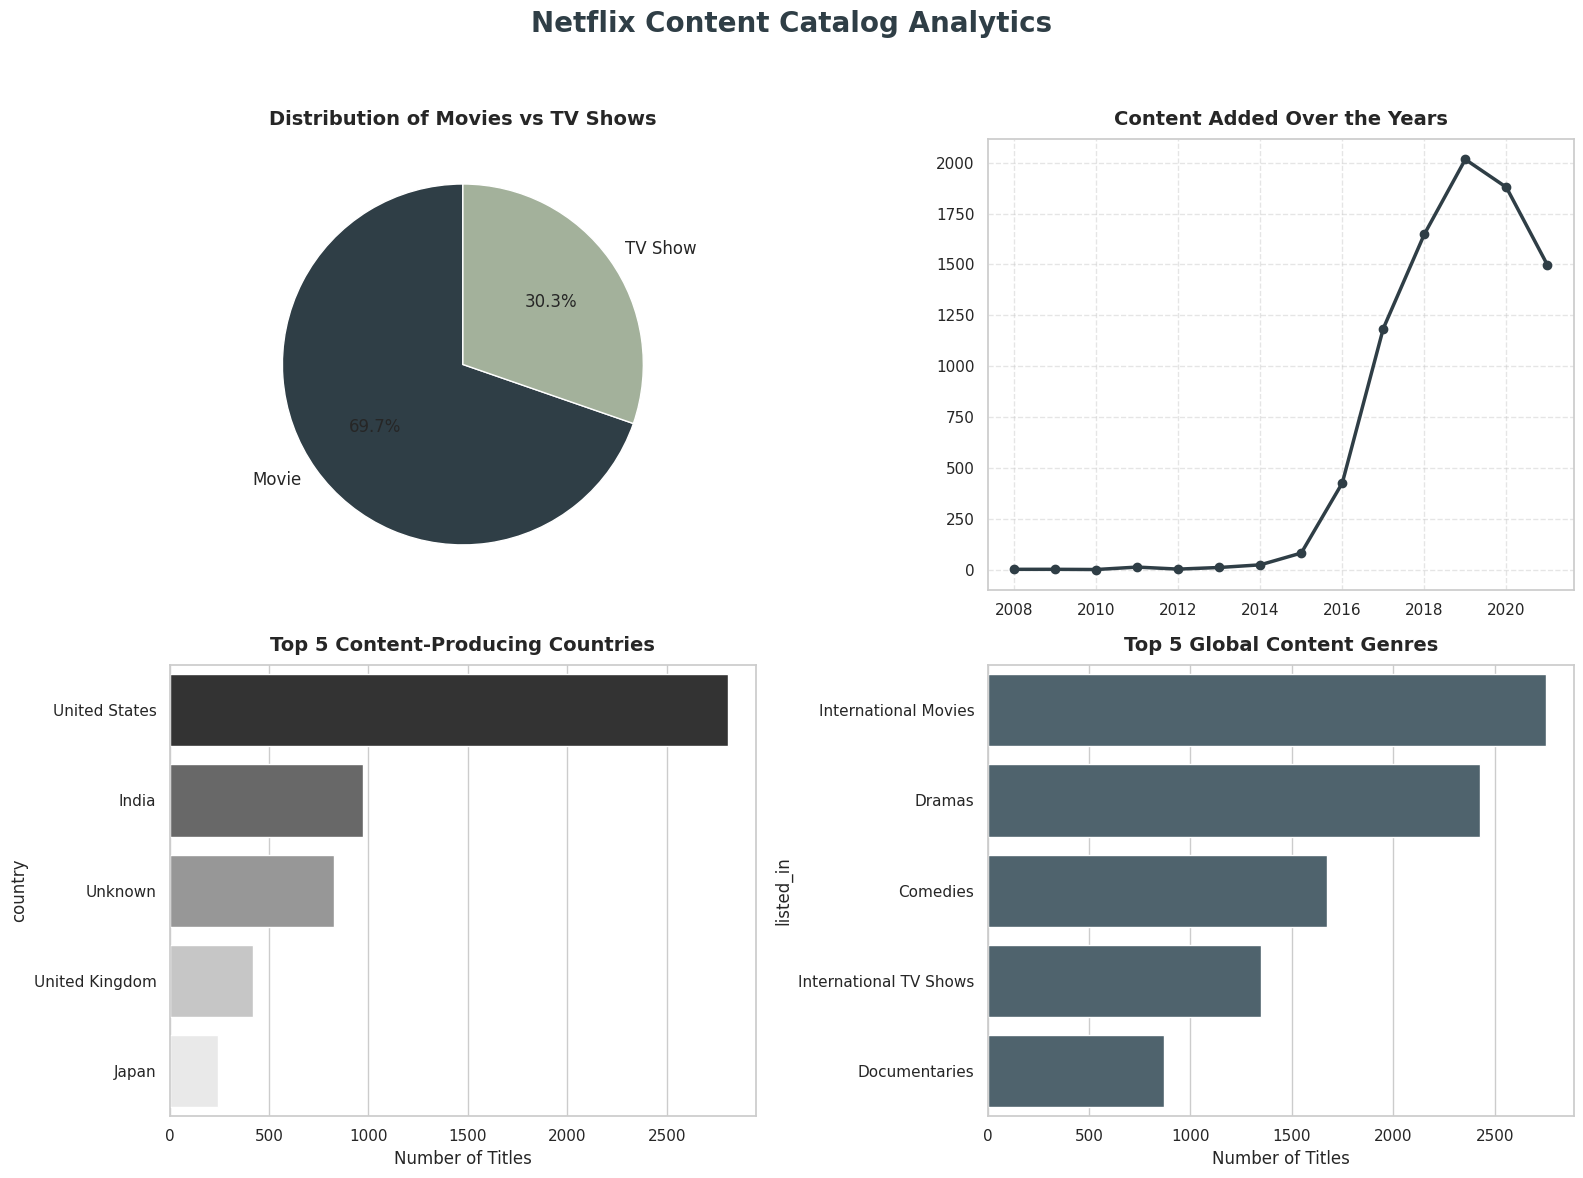

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid for Netflix
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Netflix Content Catalog Analytics", fontsize=20, fontweight='bold', color='#2F3E46', y=0.98)

# 1. Top Left: Content Type (Pie)
axes[0, 0].pie(df_netflix['type'].value_counts(), labels=df_netflix['type'].value_counts().index,
               autopct='%1.1f%%', colors=['#2F3E46', '#A3B19B'], startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title("Distribution of Movies vs TV Shows", fontsize=14, fontweight='bold', pad=10)

# 2. Top Right: Growth Trend (Line)
trend = df_netflix['year_added'].value_counts().sort_index()
axes[0, 1].plot(trend.index, trend.values, color='#2F3E46', marker='o', linewidth=2.5)
axes[0, 1].set_title("Content Added Over the Years", fontsize=14, fontweight='bold', pad=10)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# 3. Bottom Left: Top Countries (Horizontal Bar)
countries = df_netflix['country'].value_counts().head(5)
sns.barplot(x=countries.values, y=countries.index, palette="Greys_r", ax=axes[1, 0])
axes[1, 0].set_title("Top 5 Content-Producing Countries", fontsize=14, fontweight='bold', pad=10)
axes[1, 0].set_xlabel("Number of Titles")

# 4. Bottom Right: Top Genres (Horizontal Bar - Solid Slate Color)
genres = df_netflix['listed_in'].str.split(', ').explode().value_counts().head(5)
sns.barplot(x=genres.values, y=genres.index, color="#4A6572", ax=axes[1, 1])
axes[1, 1].set_title("Top 5 Global Content Genres", fontsize=14, fontweight='bold', pad=10)
axes[1, 1].set_xlabel("Number of Titles")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [45]:
# Save the final cleaned datasets to CSV files
df_retail.to_csv('cleaned_ecommerce_retail.csv', index=False)
df_netflix.to_csv('cleaned_netflix_titles.csv', index=False)

print("🎉 Success! Your cleaned datasets have been successfully saved.")

🎉 Success! Your cleaned datasets have been successfully saved.
